In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

nav['date'] = pd.to_datetime(nav['date'])

print(nav.shape)
print(performance.shape)

(46000, 3)
(40, 19)


In [20]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav[['amfi_code', 'date', 'nav', 'daily_return']].head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


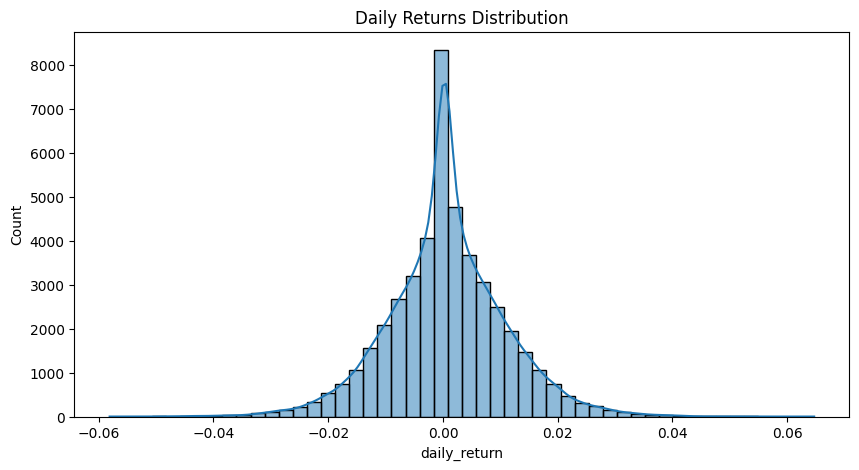

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Returns Distribution")

plt.savefig("../reports/daily_returns_distribution.png",
            bbox_inches="tight")

plt.show()

In [22]:
cagr_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund].sort_values('date')

    start_nav = temp['nav'].iloc[0]
    end_nav = temp['nav'].iloc[-1]

    years = (
        (temp['date'].iloc[-1] -
         temp['date'].iloc[0]).days
    ) / 365

    cagr = ((end_nav/start_nav)**(1/years)-1)*100

    cagr_data.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=['amfi_code', 'cagr_pct']
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


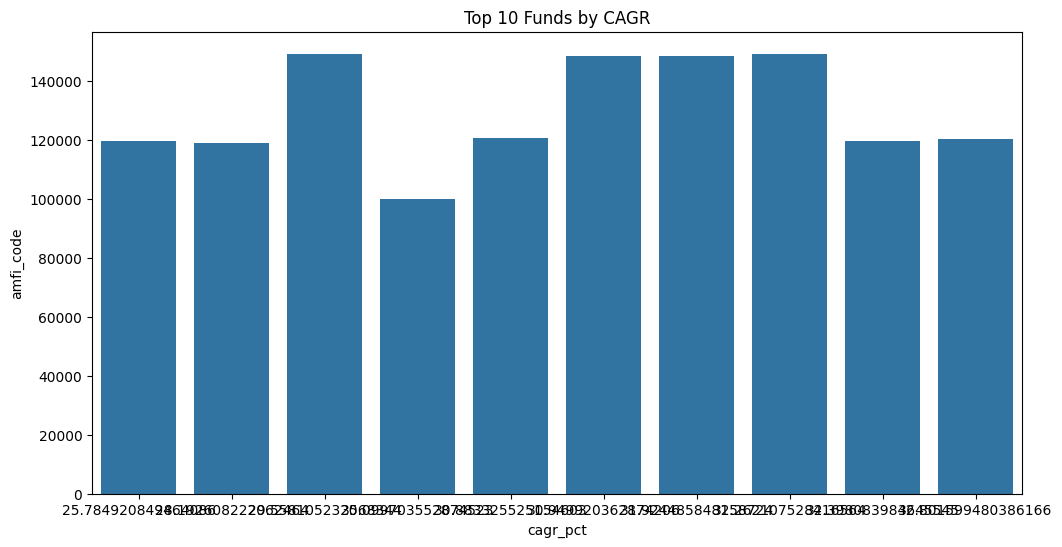

In [23]:
top_cagr = cagr_df.sort_values(
    by='cagr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x='cagr_pct',
    y='amfi_code'
)

plt.title("Top 10 Funds by CAGR")

plt.savefig(
    "../reports/top_cagr_funds.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
rf = 0.065

sharpe_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    returns = temp['daily_return'].dropna()

    if len(returns) > 30:

        annual_return = returns.mean() * 252
        annual_std = returns.std() * np.sqrt(252)

        sharpe = (annual_return - rf) / annual_std

        sharpe_data.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=['amfi_code', 'sharpe_ratio']
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


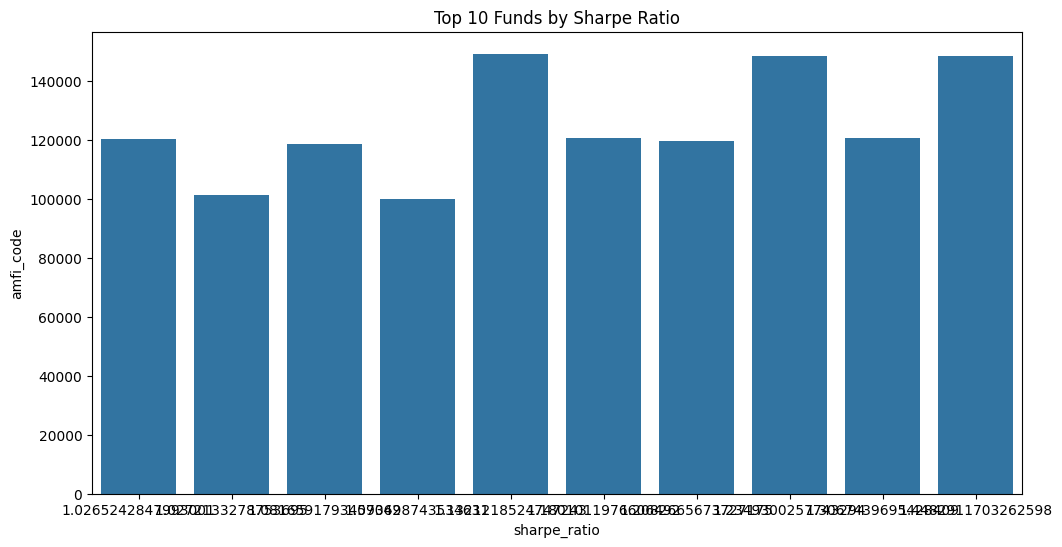

In [25]:
top_sharpe = sharpe_df.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='amfi_code'
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.savefig(
    "../reports/top_sharpe_ratio.png",
    bbox_inches="tight"
)

plt.show()

In [26]:
sortino_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    returns = temp['daily_return'].dropna()

    downside = returns[returns < 0]

    if len(downside) > 10:

        annual_return = returns.mean() * 252

        downside_std = (
            downside.std() * np.sqrt(252)
        )

        sortino = (
            annual_return - rf
        ) / downside_std

        sortino_data.append(
            [fund, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


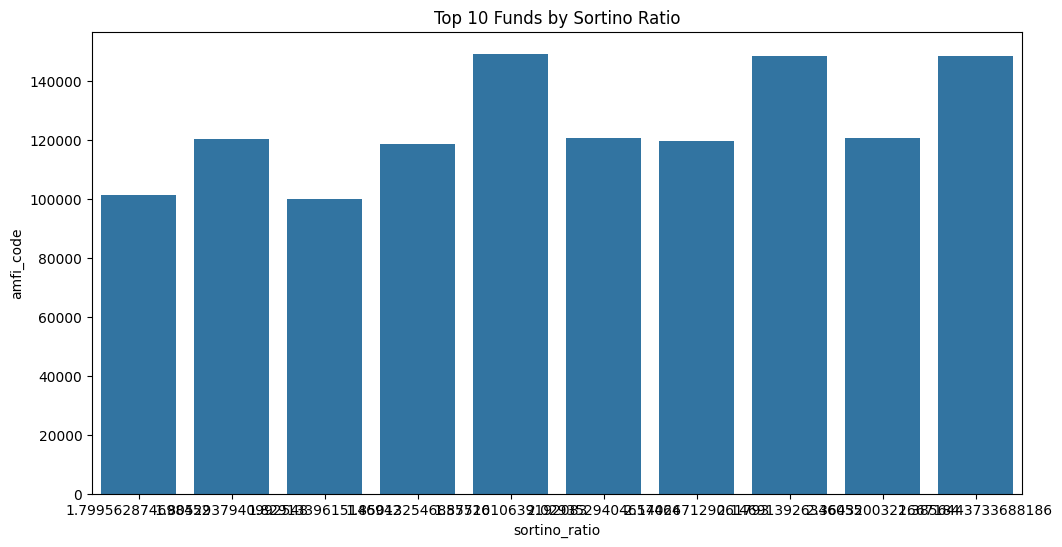

In [27]:
top_sortino = sortino_df.sort_values(
    by='sortino_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x='sortino_ratio',
    y='amfi_code'
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.savefig(
    "../reports/top_sortino_ratio.png",
    bbox_inches="tight"
)

plt.show()

In [28]:
drawdown_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund].copy()

    temp = temp.sort_values('date')

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav'] /
        temp['running_max']
        - 1
    )

    max_dd = temp['drawdown'].min()

    drawdown_data.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


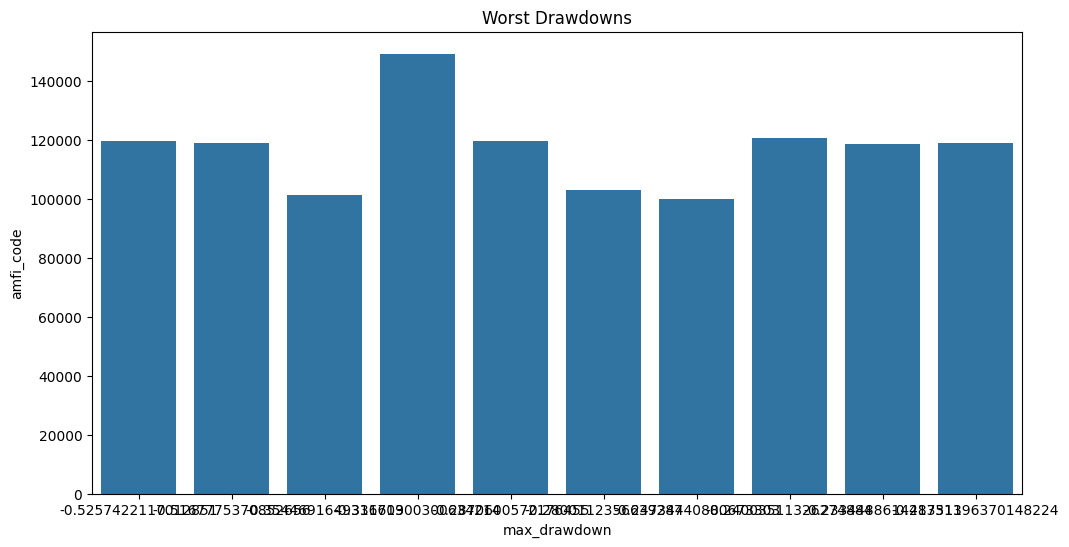

In [29]:
top_dd = drawdown_df.sort_values(
    by='max_drawdown'
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_dd,
    x='max_drawdown',
    y='amfi_code'
)

plt.title("Worst Drawdowns")

plt.savefig(
    "../reports/worst_drawdowns.png",
    bbox_inches="tight"
)

plt.show()

In [30]:
alpha_beta = performance[
    [
        'amfi_code',
        'alpha',
        'beta'
    ]
]

alpha_beta.head()

,amfi_code,alpha,beta
0,119551,0.87,0.89
1,119552,1.78,0.87
2,119598,1.23,0.89
3,119599,1.13,1.04
4,119120,1.60,0.22


In [31]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Saved")

Saved


In [32]:
scorecard = performance.copy()

scorecard['return_rank'] = (
    scorecard['return_3yr_pct']
    .rank(ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

In [33]:
scorecard = scorecard.merge(
    sharpe_df,
    on='amfi_code',
    how='left'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code',
    how='left'
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

KeyError: 'sharpe_ratio'

In [ ]:
print(sharpe_df.head())
print(sharpe_df.columns)
print(sharpe_df.shape)

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661
Index(['amfi_code', 'sharpe_ratio'], dtype='str')
(40, 2)


In [ ]:
print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_rank', 'alpha_rank', 'expense_rank', 'sharpe_ratio_y', 'max_drawdown']


In [ ]:
scorecard = scorecard.merge(
    sharpe_df[['amfi_code','sharpe_ratio']],
    on='amfi_code',
    how='left'
)

print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_rank', 'alpha_rank', 'expense_rank', 'sharpe_ratio_y', 'max_drawdown', 'sharpe_ratio']


In [ ]:
scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

In [ ]:
scorecard['score'] = (
    scorecard['return_rank'] * 0.30 +
    scorecard['sharpe_rank'] * 0.25 +
    scorecard['alpha_rank'] * 0.20 +
    scorecard['expense_rank'] * 0.15 +
    scorecard['drawdown_rank'] * 0.10
)

scorecard = scorecard.sort_values(
    by='score'
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,risk_grade,return_rank,alpha_rank,expense_rank,sharpe_ratio_y,max_drawdown,sharpe_ratio,sharpe_rank,drawdown_rank,score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,Moderately High,11.0,3.5,22.0,1.306744,-0.129740,1.306744,2.0,13.0,9.100
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,Moderate,17.0,12.0,23.0,1.448291,-0.112657,1.448291,1.0,8.0,12.000
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,High,8.0,29.5,15.0,1.180101,-0.181885,1.180101,5.0,25.0,14.300
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,High,10.0,26.0,17.0,1.093699,-0.162172,1.093699,7.0,20.0,14.500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,Very High,1.0,20.0,21.0,0.945308,-0.287060,0.945308,14.0,36.0,14.550
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,...,High,15.0,16.0,17.0,0.998231,-0.209609,0.998231,11.0,28.0,15.800
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,Moderate,34.0,9.0,4.0,0.953279,-0.118035,0.953279,12.0,11.0,16.700
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,Very High,3.0,5.0,28.5,0.162661,-0.354469,0.162661,28.0,38.0,16.975
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,...,High,9.0,25.0,38.0,1.132122,-0.172481,1.132122,6.0,22.0,17.100
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,...,Moderately High,19.0,10.5,26.5,0.926287,-0.152726,0.926287,15.0,19.0,17.425


In [ ]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


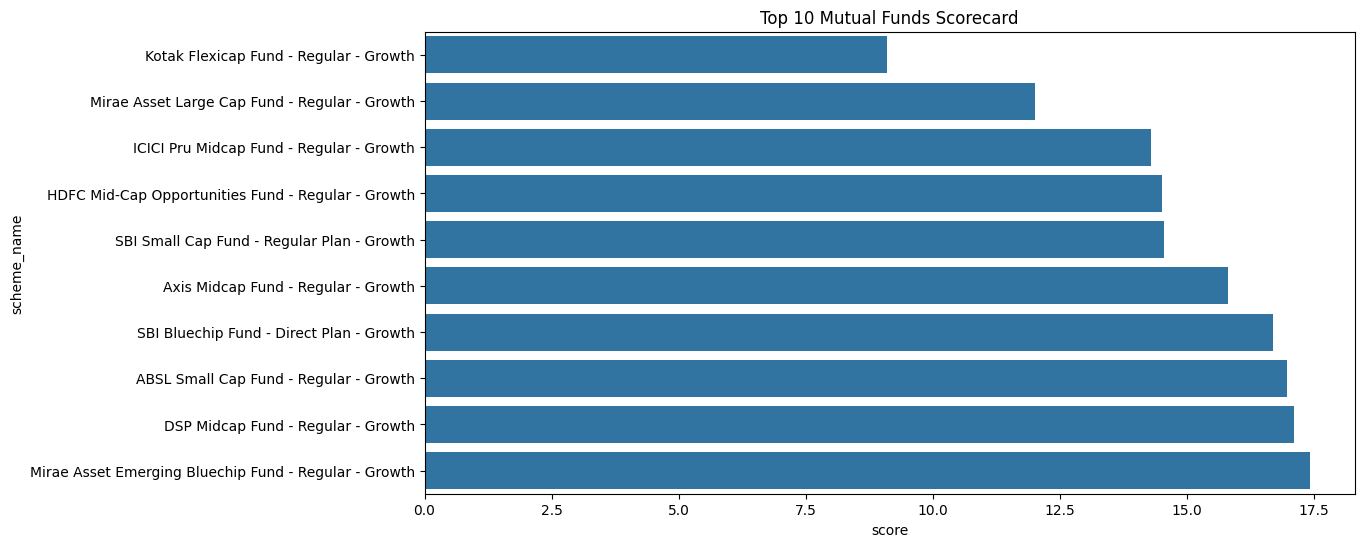

In [ ]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='score',
    y='scheme_name'
)

plt.title("Top 10 Mutual Funds Scorecard")

plt.savefig(
    "../reports/top_fund_scorecard.png",
    bbox_inches="tight"
)

plt.show()

# Day 4 Findings

- Calculated Sharpe Ratio for all mutual funds.
- Calculated Sortino Ratio using downside risk.
- Computed Maximum Drawdown for each fund.
- Created Alpha and Beta comparison dataset.
- Generated Fund Scorecard based on return, risk and expense metrics.
- Identified top-performing funds using composite ranking.
- Exported CSV files and visualizations for reporting.


In [ ]:
nav.columns.tolist()

['amfi_code', 'date', 'nav', 'daily_return']

In [ ]:
scorecard[['amfi_code','scheme_name']].head()

,amfi_code,scheme_name
22,120843,Kotak Flexicap Fund - Regular - Growth
34,148567,Mirae Asset Large Cap Fund - Regular - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,119598,SBI Small Cap Fund - Regular Plan - Growth


In [ ]:
scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,risk_grade,return_rank,alpha_rank,expense_rank,sharpe_ratio_y,max_drawdown,sharpe_ratio,sharpe_rank,drawdown_rank,score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,Moderately High,11.0,3.5,22.0,1.306744,-0.129740,1.306744,2.0,13.0,9.10
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,Moderate,17.0,12.0,23.0,1.448291,-0.112657,1.448291,1.0,8.0,12.00
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,High,8.0,29.5,15.0,1.180101,-0.181885,1.180101,5.0,25.0,14.30
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,High,10.0,26.0,17.0,1.093699,-0.162172,1.093699,7.0,20.0,14.50
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,Very High,1.0,20.0,21.0,0.945308,-0.287060,0.945308,14.0,36.0,14.55


In [ ]:
top5 = scorecard.sort_values("score", ascending=False).head(5)

top5_codes = top5["amfi_code"].tolist()

top5_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

top5_nav["date"] = pd.to_datetime(top5_nav["date"])

funds_pivot = top5_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

funds_norm = funds_pivot / funds_pivot.iloc[0] * 100

KeyError: 'score'

In [34]:
import pandas as pd

scorecard = pd.read_csv("../reports/fund_scorecard.csv")

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,risk_grade,return_rank,alpha_rank,expense_rank,sharpe_ratio_y,max_drawdown,sharpe_ratio,sharpe_rank,drawdown_rank,score
0,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,Moderately High,11.0,3.5,22.0,1.306744,-0.129740,1.306744,2.0,13.0,9.10
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,Moderate,17.0,12.0,23.0,1.448291,-0.112657,1.448291,1.0,8.0,12.00
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,High,8.0,29.5,15.0,1.180101,-0.181885,1.180101,5.0,25.0,14.30
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,High,10.0,26.0,17.0,1.093699,-0.162172,1.093699,7.0,20.0,14.50
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,Very High,1.0,20.0,21.0,0.945308,-0.287060,0.945308,14.0,36.0,14.55


In [35]:
top5 = scorecard.sort_values(
    "score",
    ascending=True
).head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[120843, 148567, 120505, 100033, 119598]


In [36]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

funds_pivot = top5_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

funds_norm = (
    funds_pivot /
    funds_pivot.iloc[0]
) * 100

funds_norm.head()

amfi_code,100033,119598,120505,120843,148567
date,,,,,
2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000
2022-01-04,98.667204,98.526489,98.010039,101.815956,101.931776
2022-01-05,98.234425,98.017999,100.984824,100.563179,101.530219
2022-01-06,97.726862,98.490884,100.488327,101.418866,102.737597
2022-01-07,97.165097,101.724307,101.458505,100.052091,102.790549


In [38]:
benchmark = pd.DataFrame(index=funds_norm.index)

benchmark["Nifty50"] = [
    100 * ((1 + 0.0004) ** i)
    for i in range(len(benchmark))
]

benchmark["Nifty100"] = [
    100 * ((1 + 0.00035) ** i)
    for i in range(len(benchmark))
]

benchmark.head()

,Nifty50,Nifty100
date,,
2022-01-03,100.000000,100.000000
2022-01-04,100.040000,100.035000
2022-01-05,100.080016,100.070012
2022-01-06,100.120048,100.105037
2022-01-07,100.160096,100.140074


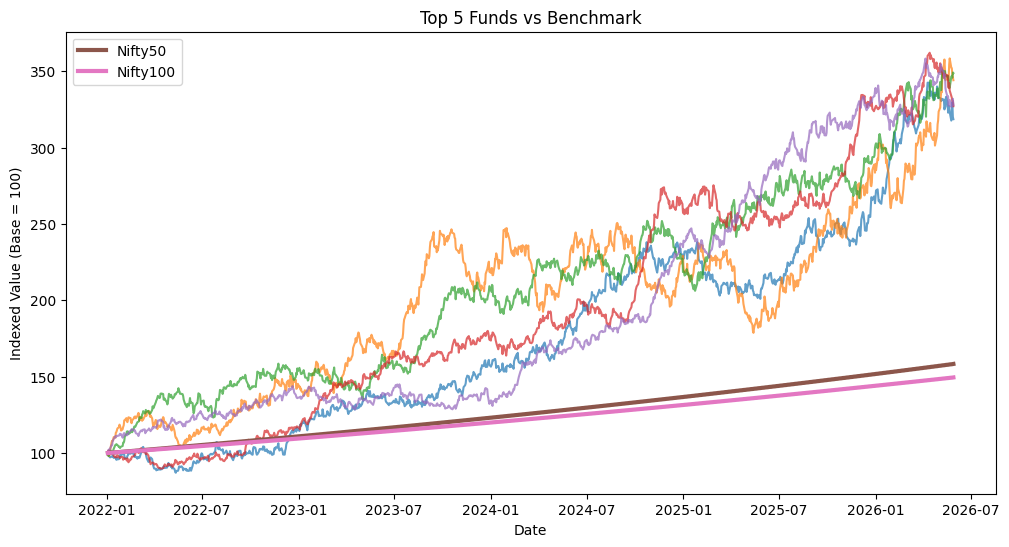

In [39]:
plt.figure(figsize=(12,6))

for col in funds_norm.columns:
    plt.plot(
        funds_norm.index,
        funds_norm[col],
        alpha=0.7
    )

plt.plot(
    benchmark.index,
    benchmark["Nifty50"],
    linewidth=3,
    label="Nifty50"
)

plt.plot(
    benchmark.index,
    benchmark["Nifty100"],
    linewidth=3,
    label="Nifty100"
)

plt.title("Top 5 Funds vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Indexed Value (Base = 100)")
plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [41]:
tracking_error = []

for col in funds_norm.columns:

    fund_ret = funds_norm[col].pct_change().dropna()

    bench_ret = benchmark["Nifty50"].pct_change().dropna()

    common_dates = fund_ret.index.intersection(
        bench_ret.index
    )

    te = (
        (fund_ret.loc[common_dates]
         - bench_ret.loc[common_dates])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [col, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,100033,0.189367
1,119598,0.251406
2,120505,0.192909
3,120843,0.158870
4,148567,0.141937


In [42]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error Saved")

Tracking Error Saved
